1. RF classifier (no hyperparameter tuning)
2. MS degree centrality percentile 

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, pearsonr
from tqdm import trange
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
import shap

#DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../../flatten/processed-data/"
#DATA_PATH3 = "../../18-Y2H-data/processed-data/"
#ABUNDANCE  = "../../0-download-inputs/data-files/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"
MS_COLOR_LIGHT = "#EECC66" #color for static (in complex)
MS_COLOR_DARK  = "#997700" #color for dynamic (not in complex)

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [2]:
# load the datasets with node centrality information and get nodes in both
#ms_nodes = pd.read_pickle(f"{DATA_PATH2}20251023-s288c-annotated-PPI-net.pkl")
#y2h_nodes = pd.read_csv(f"{DATA_PATH3}Y2H-s288c-step18.csv")
nodes = pd.read_pickle(f"{DATA_PATH2}20251209-s288c-annotated-PPI-net.pkl")

# --- Flip sign of cagiada-dG ---
nodes["cagiada-dG"] = -nodes["cagiada-dG"]

# CHAPERONE CATEGORY: three-way classification ===
def fix_list(val):
    if isinstance(val, list):
        return val
    elif isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return []
    elif pd.isnull(val):
        return []
    else:
        return []

nodes['interacting_chaperones'] = nodes['interacting_chaperones'].apply(fix_list)

def chaperone_category(row):
    node = row['node']
    chaps = row['interacting_chaperones']
    if not chaps or chaps == []:
        return 'protein_is_neither_chaperone_nor_interacts'
    elif node in chaps:
        return 'protein_is_chaperone'
    else:
        return 'protein_interacts_with_chaperone'

nodes['chaperone_category'] = nodes.apply(chaperone_category, axis=1)

# ONE-HOT ENCODE CHAPERONE CATEGORY
nodes['is_chaperone'] = (nodes['chaperone_category'] == 'protein_is_chaperone').astype(int)
nodes['interacts_with_chaperone'] = (nodes['chaperone_category'] == 'protein_interacts_with_chaperone').astype(int)
nodes['neither_chaperone_nor_interacts'] = (nodes['chaperone_category'] == 'protein_is_neither_chaperone_nor_interacts').astype(int)

#y2h_nodes = y2h_nodes.merge(abundance_df, on="node", how="left")

#shared_nodes = set(ms_nodes["node"]) & set(y2h_nodes["node"])
#print (f"A total of {len(shared_nodes)} nodes are shared between the MS and Y2H networks")
#list(nodes.columns)


In [3]:
# Filter nodes to remove proteins with low pLDDT and/or are membrane proteins (TM) with/without signal peptide (SP)
filtered_nodes = nodes[
    (nodes['mean_plddt'] >= 70) &
    (~nodes['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()

# Print stats to for nodes
print(f"Original rows: {len(nodes)}")
print(f"Filtered rows: {len(filtered_nodes)}")

Original rows: 3927
Filtered rows: 2466


In [4]:
# determine which nodes are hubs based on percentile cutoff for degree centrality
cut = 0.10
ms_threshold = filtered_nodes['degree_centrality'].quantile(1 - cut)
ms_hubs     = filtered_nodes[filtered_nodes['degree_centrality'] >= ms_threshold]
ms_nothub   = filtered_nodes[filtered_nodes['degree_centrality'] <  ms_threshold]

#y2h_threshold = filtered_nodes['Y2H_degree_centrality'].quantile(1 - cut)
#y2h_hubs      = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] >= y2h_threshold]
#y2h_nothub    = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] <  y2h_threshold]

print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")
#print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in MS data is 0.01503; there are 252 hubs and 2214 non hubs


In [5]:
# SCRIPT 2: Feature & Target Preparation
# Create target column if not already created
filtered_nodes['ms_hubs'] = (filtered_nodes['degree_centrality'] >= ms_threshold).astype(int)

# 2. Feature & Target Preparation
ml_features = [
    'Ghosh-Dill-dG', 'cagiada-dG', 'Rosetta_best_total_score',
    'Villen_halflife_min',
    'mean_molecules_per_cell',
    'interacts_with_chaperone', 'in_complex',
    'essential',
    'meltome-melting-point', 'N_aa_disordered', 'disorder_fraction', 'mean_plddt'
]

X = filtered_nodes[ml_features].copy()
y = filtered_nodes['ms_hubs'].copy()

# Replace common string indicators of missing values with NaN, then convert to numeric
missing_indicators = [
    'n.d.', 'N.D.', 'nd', 'ND', 'na', 'NA', 'null', 'NULL',
    'missing', 'MISSING', '-', 'n/a', 'N/A', ''
]

for col in ml_features:
    X[col] = X[col].replace(missing_indicators, np.nan)
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Fill remaining NaNs with -999 (important for sklearn RF)
X_filled = X.fillna(-999)

print("✅ Data preparation complete")
print(f"Total usable samples: {len(X_filled)}")

✅ Data preparation complete
Total usable samples: 2466


In [6]:
# SCRIPT : Basic Random Forest (no hyperparameter tuning)
# -------------------------------------------
# 1. Train-Test Split
# -------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_filled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Data split completed:")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Training class ratio (High PME): {np.mean(y_train)*100:.1f}%")

# -------------------------------------------
# 2. Random Forest Model Training
# -------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

print("Random Forest model trained.")

# -------------------------------------------
# 3. Evaluation
# -------------------------------------------
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

bal_accuracy = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("\nModel Performance:")
print(f"Balanced Accuracy: {bal_accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print(f"True Positive Rate: {tp/(tp+fn):.3f}")
print(f"False Positive Rate: {fp/(fp+tn):.3f}")

# -------------------------------------------
# 4. SHAP Feature Importance
# -------------------------------------------
print("\nComputing SHAP values...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Handle output shape depending on SHAP version
if isinstance(shap_values, list):
    shap_class_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_class_values = shap_values[:, :, 1]
else:
    shap_class_values = shap_values




Data split completed:
Training samples: 1972
Test samples: 494
Training class ratio (High PME): 10.2%
Random Forest model trained.

Model Performance:
Balanced Accuracy: 0.785
Precision: 0.879
Recall: 0.580
F1 Score: 0.699
ROC-AUC: 0.972

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       444
           1       0.88      0.58      0.70        50

    accuracy                           0.95       494
   macro avg       0.92      0.79      0.84       494
weighted avg       0.95      0.95      0.94       494

Confusion Matrix:
TP: 29, FP: 4, TN: 440, FN: 21
True Positive Rate: 0.580
False Positive Rate: 0.009

Computing SHAP values...


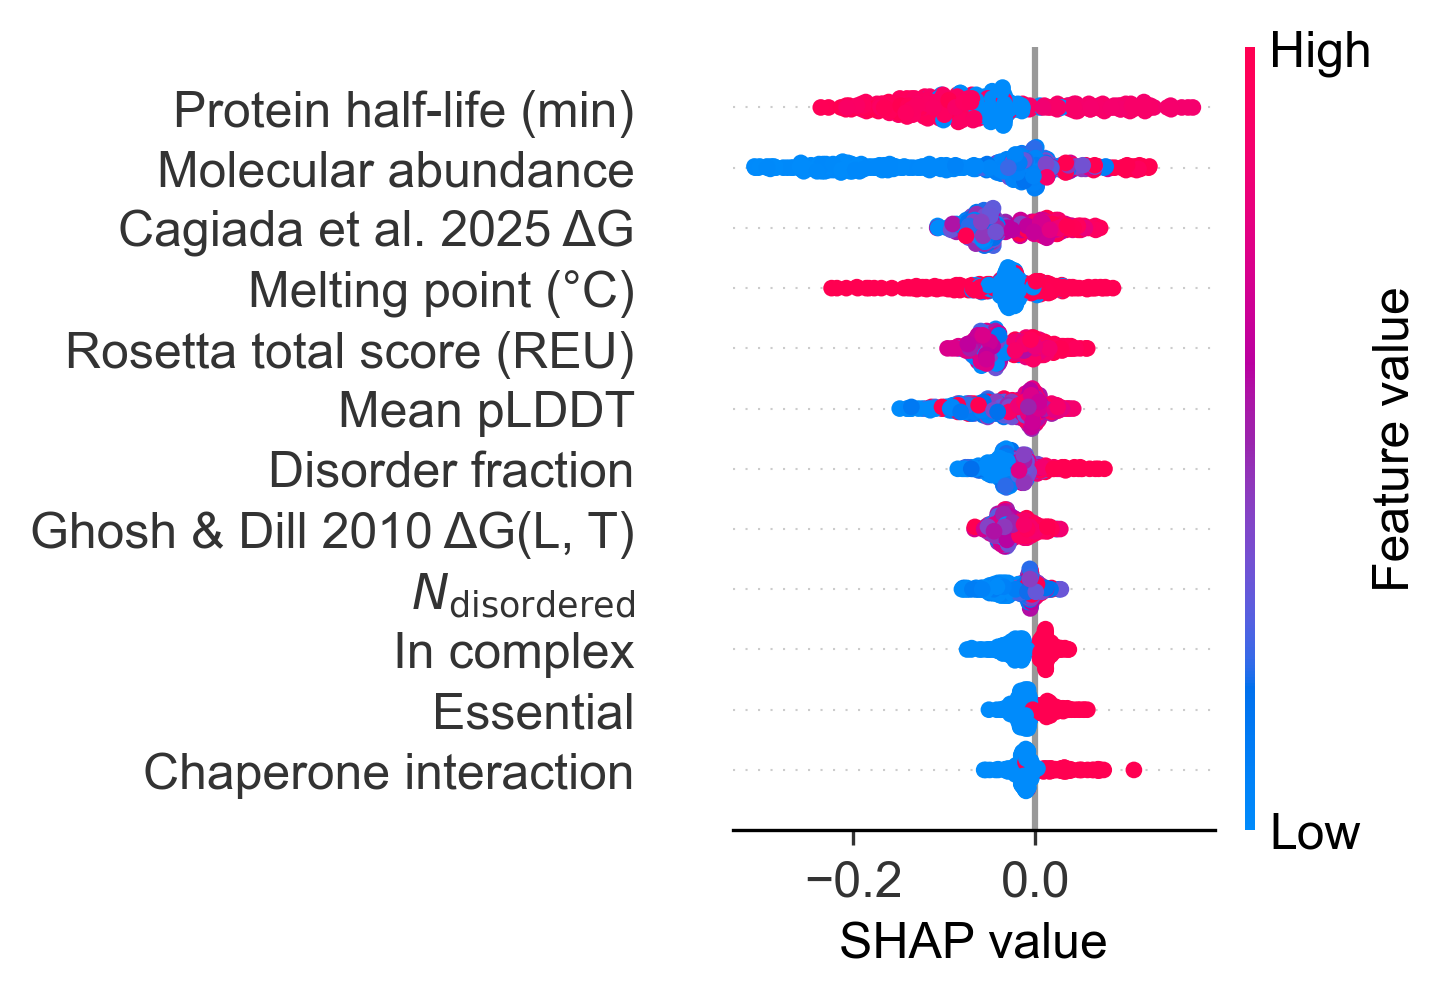

In [7]:
# Map original feature names to publication labels
rename_map = {
    'Ghosh-Dill-dG': 'Ghosh & Dill 2010 ΔG(L, T)', 
    'cagiada-dG': 'Cagiada et al. 2025 ΔG', 
    'Rosetta_best_total_score': 'Rosetta total score (REU)',
    'Villen_halflife_min': 'Protein half-life (min)',
    'mean_molecules_per_cell': 'Molecular abundance',
    'interacts_with_chaperone': 'Chaperone interaction', 
    'in_complex': 'In complex',
    'essential': 'Essential',
    'meltome-melting-point': 'Melting point (°C)',  
    'N_aa_disordered': r"$N_{\mathrm{disordered}}$",
    'disorder_fraction': 'Disorder fraction', 
    'mean_plddt': 'Mean pLDDT'
}

# Prepare display names for SHAP plot - use actual feature names from X_train
feature_names_list = list(X_train.columns)
display_names = [rename_map.get(f, f) for f in feature_names_list]

# SHAP Summary Plot (top 10 features)
fig, ax = plt.subplots(figsize=(2, 2))
shap.summary_plot(
    shap_class_values,
    X_test,
    feature_names=display_names,
    plot_type='dot',
    max_display=12,
    show=False
)
# Get the figure SHAP created
fig = plt.gcf()
ax = plt.gca()
# --- FORCE SHAP FONT STYLES (Arial, bold, size 11) ---
for text in fig.findobj(match=plt.Text):
    text.set_fontfamily("Arial")
    text.set_fontsize(12)
    text.set_fontweight("normal")
# Fix axis labels & ticks
ax.set_xlabel("SHAP value", fontsize=12, fontweight="normal", fontfamily="Arial")
ax.set_ylabel("", fontsize=12, fontweight="normal", fontfamily="Arial")

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily("Arial")
    label.set_fontsize(12)
    label.set_fontweight("normal")
plt.tight_layout()

# Save as high-resolution PDF
fig.set_size_inches(3, 3)
plt.savefig('SHAP_random_forest1.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()


Random Forest Gini-based Feature Importances:
                 Feature  Gini Importance
 mean_molecules_per_cell         0.210033
     Villen_halflife_min         0.175512
   meltome-melting-point         0.097629
Rosetta_best_total_score         0.093472
              cagiada-dG         0.087512
              mean_plddt         0.085576
           Ghosh-Dill-dG         0.071794
       disorder_fraction         0.060936
         N_aa_disordered         0.052998
interacts_with_chaperone         0.023178
              in_complex         0.021234
               essential         0.020127

Generating ROC data...
ROC Data Summary:
Points: 48
AUC Score: 0.971532

Complete ROC Data (Copy/Paste for Origin):
# False_Positive_Rate	True_Positive_Rate	Threshold	Specificity	Sensitivity	Point_Index	Youden_J	Distance_to_Perfect
0.00000000	0.00000000	inf	1.00000000	0.00000000	0.0	0.00000000	1.00000000
0.00000000	0.02000000	0.92233268	1.00000000	0.02000000	1.0	0.02000000	0.98000000
0.00000000	0.500000

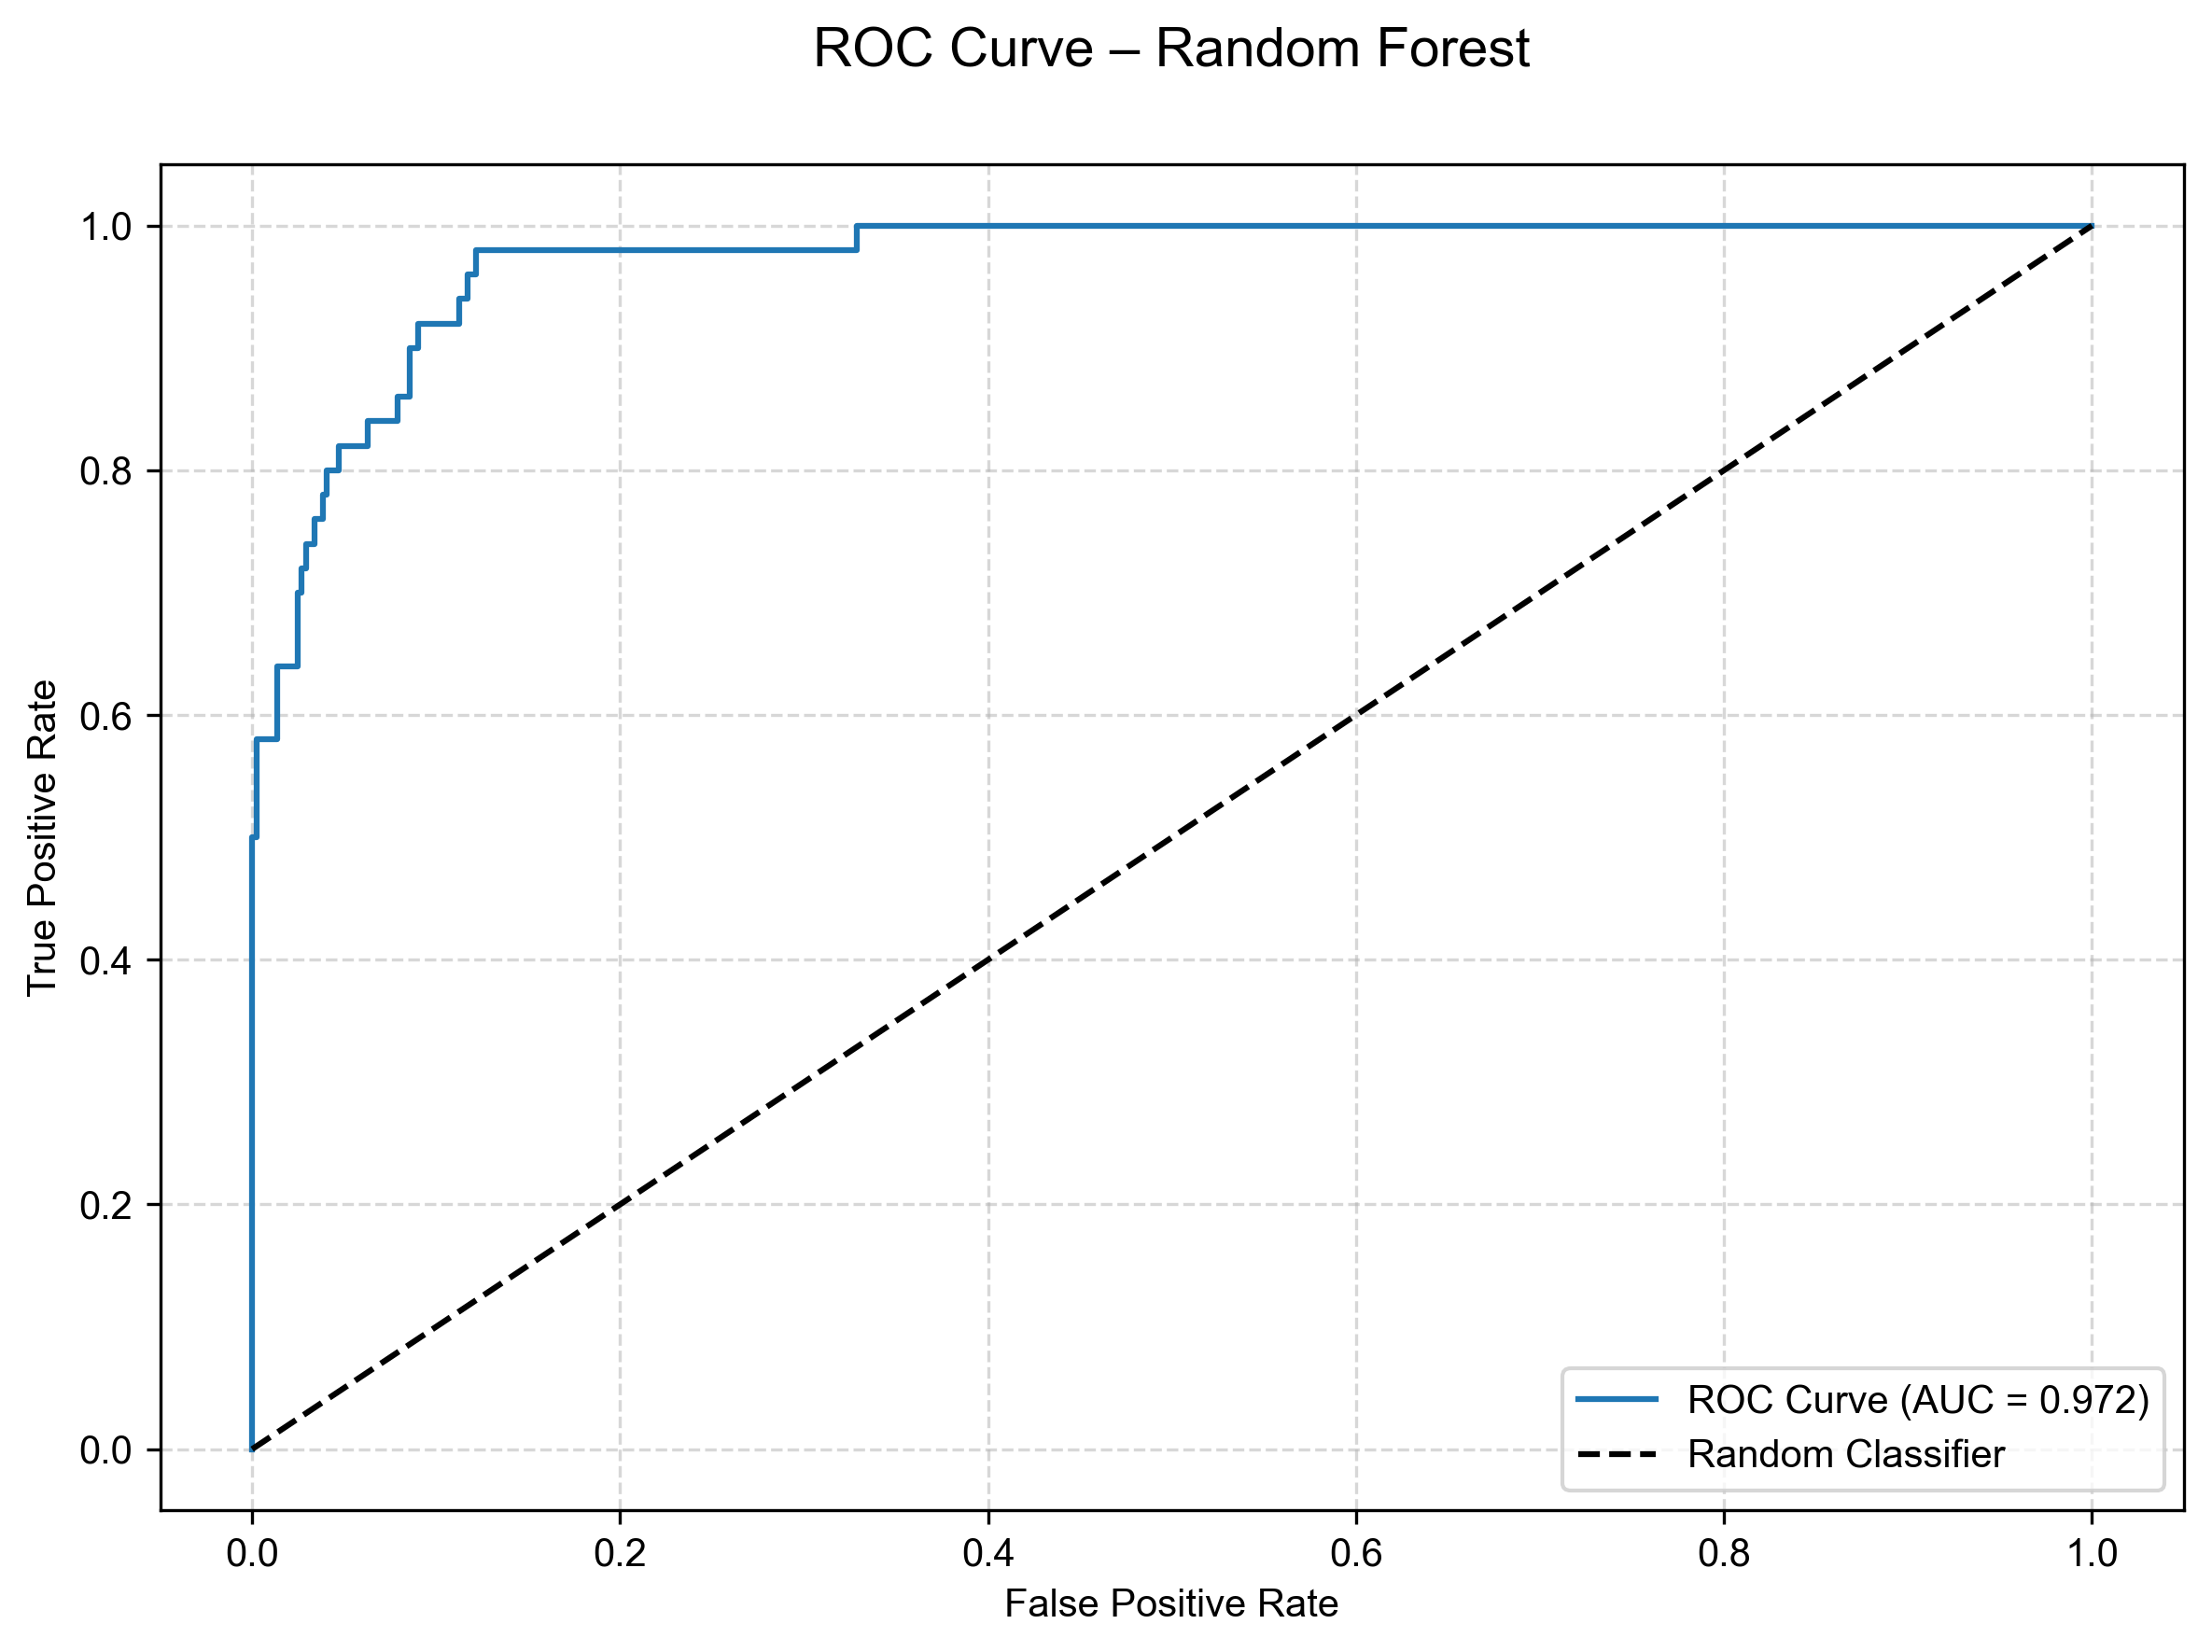

In [8]:
# -------------------------------------------
# 5. Gini Feature Importances
# -------------------------------------------
print("\nRandom Forest Gini-based Feature Importances:")
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names_list,
    'Gini Importance': importances
}).sort_values(by='Gini Importance', ascending=False)

print(importance_df.to_string(index=False))

# -------------------------------------------
# 6. Generate ROC Data Table for Origin
# -------------------------------------------
print("\nGenerating ROC data...")

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_df = pd.DataFrame({
    'False_Positive_Rate': fpr,
    'True_Positive_Rate': tpr,
    'Threshold': thresholds,
    'Specificity': 1 - fpr,
    'Sensitivity': tpr,
    'Point_Index': range(len(fpr))
})

roc_df['Youden_J'] = roc_df['Sensitivity'] + roc_df['Specificity'] - 1
roc_df['Distance_to_Perfect'] = np.sqrt((fpr - 0)**2 + (tpr - 1)**2)

print("ROC Data Summary:")
print(f"Points: {len(roc_df)}")
print(f"AUC Score: {roc_auc:.6f}")

print("\nComplete ROC Data (Copy/Paste for Origin):")
print("# False_Positive_Rate\tTrue_Positive_Rate\tThreshold\tSpecificity\tSensitivity\tPoint_Index\tYouden_J\tDistance_to_Perfect")

for idx, row in roc_df.iterrows():
    print(f"{row['False_Positive_Rate']:.8f}\t{row['True_Positive_Rate']:.8f}\t{row['Threshold']:.8f}\t"
          f"{row['Specificity']:.8f}\t{row['Sensitivity']:.8f}\t{row['Point_Index']}\t"
          f"{row['Youden_J']:.8f}\t{row['Distance_to_Perfect']:.8f}")

# -------------------------------------------
# 7. Plot ROC Curve
# -------------------------------------------
plt.figure(figsize=(8, 6))
plt.plot(roc_df['False_Positive_Rate'], roc_df['True_Positive_Rate'], label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()